# 05 - Inference Pipeline
Full two-stage pipeline: Stage 1 (Mel vs Not Mel) -> Stage 2 (specific disease) with ground-truth comparison, organized outputs, and evaluation statistics.

In [1]:
import numpy as np
import os
import sys
sys.path.append('..')

from ultralytics import YOLO

from src.inference_utils.inference_pipeline import run_inference_pipeline, compute_pipeline_statistics

stage1_model = YOLO('../outputs/checkpoints/stage-1/last.pt')
stage2_model = YOLO('../outputs/checkpoints/stage-2/last.pt')

TEST_IMAGES_PATH = '../data/processed/Stage-2/test/images'
TEST_LABELS_PATH = '../data/processed/Stage-2/test/labels'

# Maps the raw class ids inside the label .txt files to readable disease names,
# used only for the classification-accuracy statistic at the end.
GT_CLASS_NAMES = {0: 'nv', 1: 'bkl', 2: 'bcc', 3: 'akiec', 4: 'vasc', 5: 'df'}

## Single image demo (with visualization)

Running inference pipeline:   0%|          | 0/1 [00:00<?, ?it/s]


0: 192x256 122.9ms
Speed: 2.5ms preprocess, 122.9ms inference, 0.3ms postprocess per image at shape (1, 3, 192, 256)


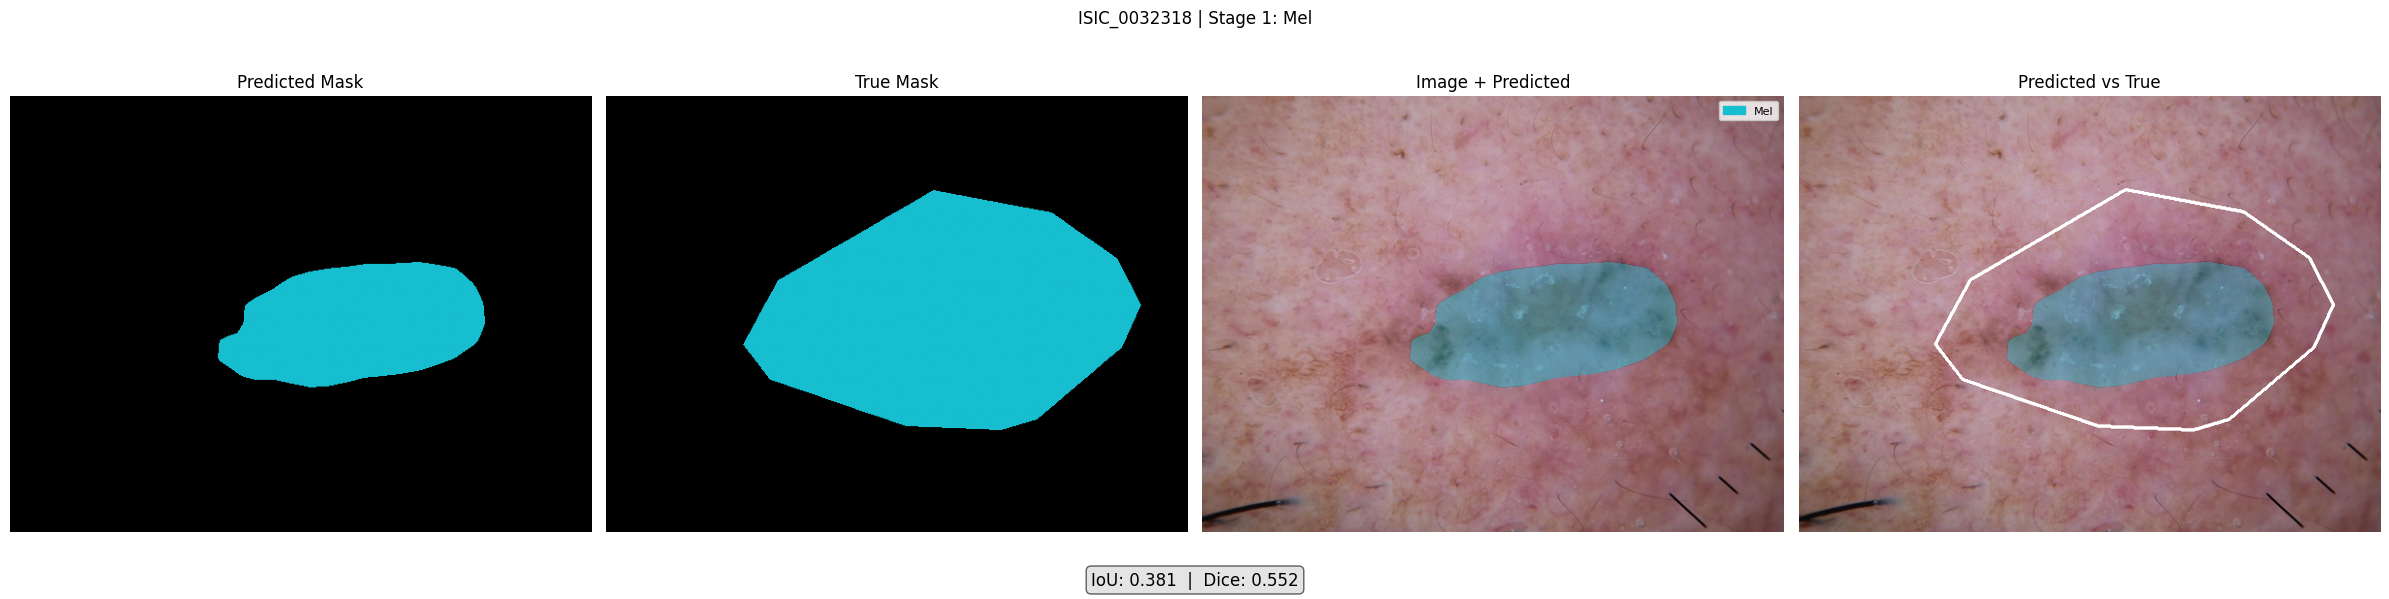

Running inference pipeline: 100%|██████████| 1/1 [00:01<00:00,  1.38s/it]


In [ ]:
one_image = np.random.choice(os.listdir(TEST_IMAGES_PATH)).split('.')[0]

results_df, warnings_list = run_inference_pipeline(
    stage1_model, stage2_model,
    images_path=TEST_IMAGES_PATH,
    labels_path=TEST_LABELS_PATH,
    image_names=one_image,      # a single string -> processes just this one image
    save_dir='../outputs/predictions/single_demo',
    visualize=True,
    gt_class_names=GT_CLASS_NAMES,
)

## A specific list of images (with visualization)

Running inference pipeline:   0%|          | 0/3 [00:00<?, ?it/s]


0: 192x256 79.8ms
Speed: 2.3ms preprocess, 79.8ms inference, 2.1ms postprocess per image at shape (1, 3, 192, 256)


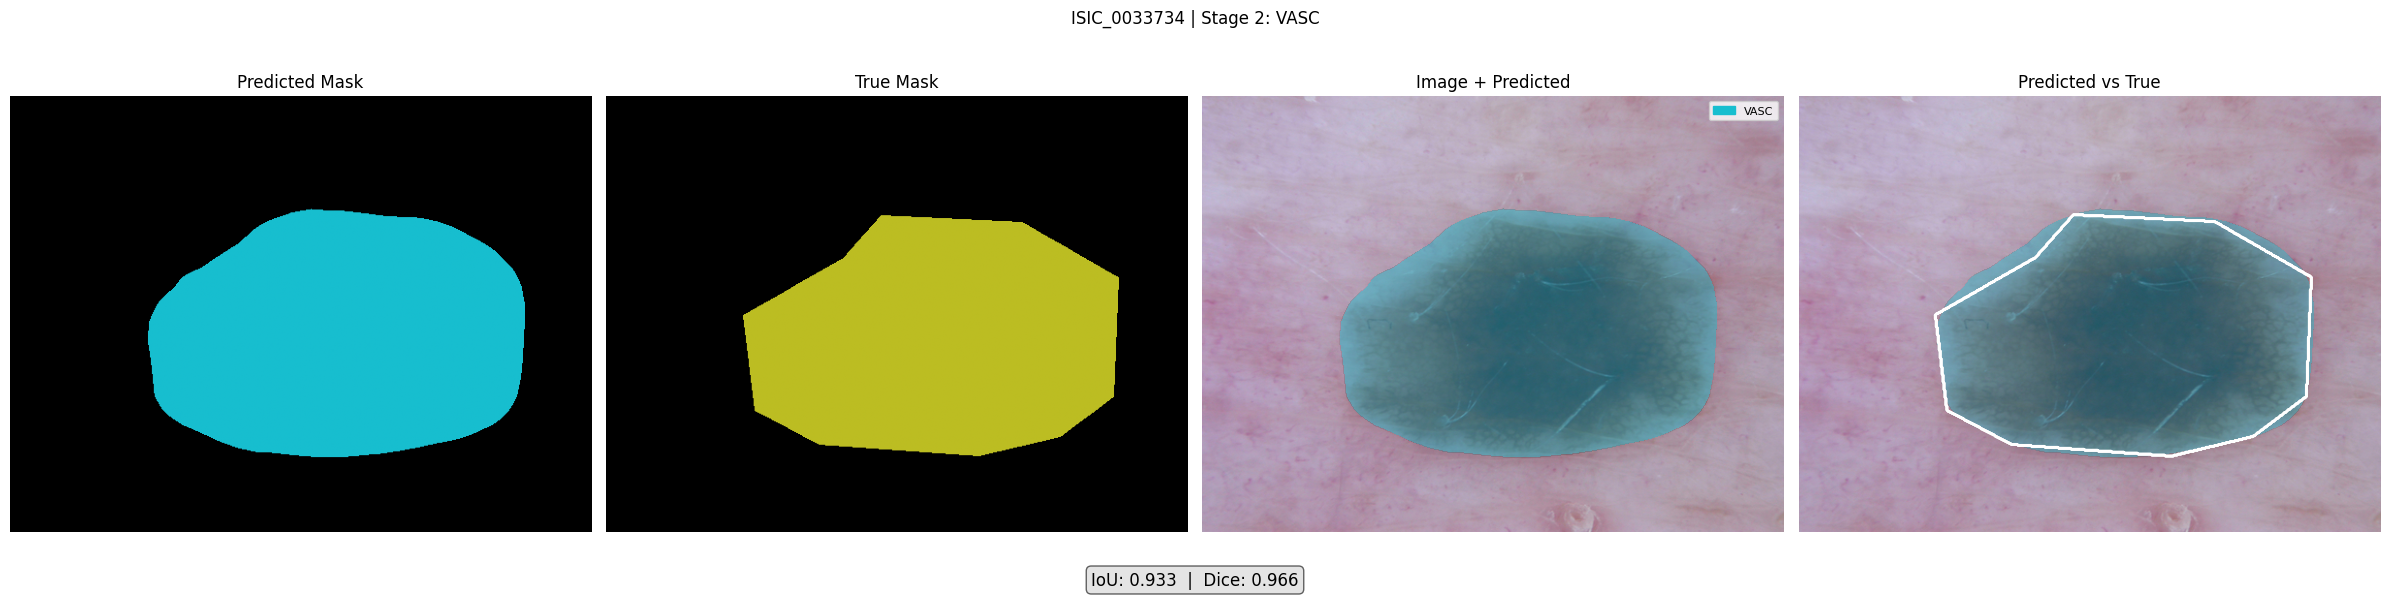

Running inference pipeline:  33%|███▎      | 1/3 [00:01<00:02,  1.37s/it]


0: 192x256 7.7ms
Speed: 1.5ms preprocess, 7.7ms inference, 0.3ms postprocess per image at shape (1, 3, 192, 256)


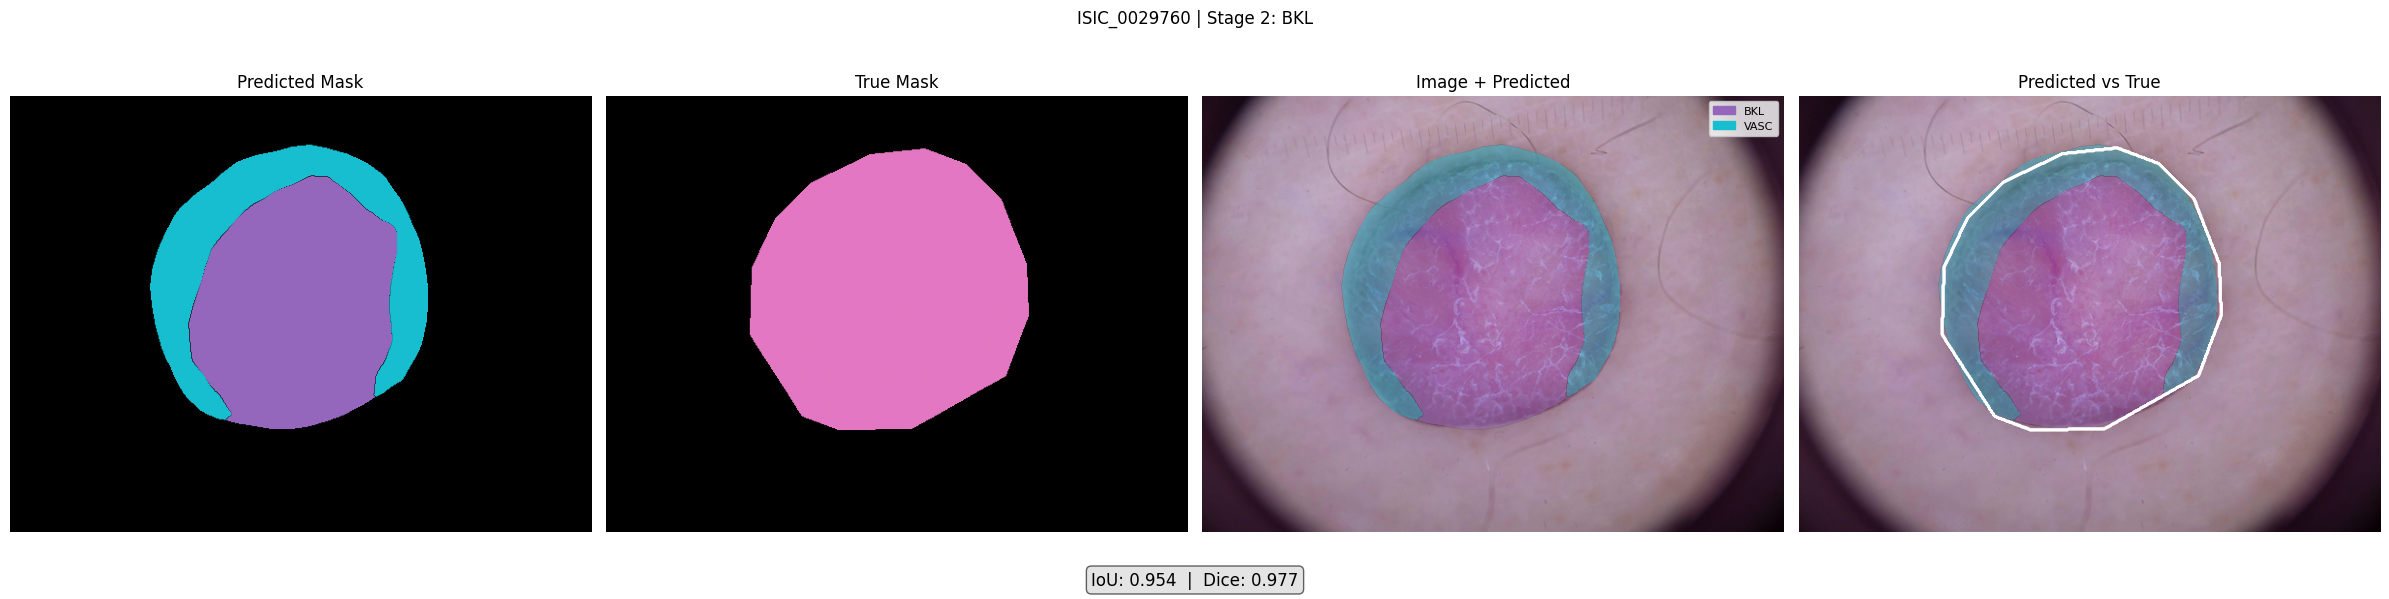

Running inference pipeline:  67%|██████▋   | 2/3 [00:03<00:01,  1.59s/it]


0: 192x256 8.0ms
Speed: 1.1ms preprocess, 8.0ms inference, 0.3ms postprocess per image at shape (1, 3, 192, 256)


Running inference pipeline: 100%|██████████| 3/3 [00:03<00:00,  1.04s/it]


,image_id,stage1_detected,stage1_prediction,stage2_detected,stage2_prediction,true_class_name,iou,dice
0,ISIC_0033734,True,Not Mel,True,VASC,vasc,0.933451,0.965580
1,ISIC_0029760,True,Not Mel,True,BKL,akiec,0.954186,0.976556
2,ISIC_0033493,False,None,None,None,vasc,NaN,NaN


In [6]:
some_images = ['ISIC_0033734', 'ISIC_0029760', 'ISIC_0033493']

results_df, warnings_list = run_inference_pipeline(
    stage1_model, stage2_model,
    images_path=TEST_IMAGES_PATH,
    labels_path=TEST_LABELS_PATH,
    image_names=some_images,
    save_dir='../outputs/predictions/sample_batch',
    visualize=True,
    gt_class_names=GT_CLASS_NAMES,
)

results_df

## Full test set (no visualization, just processing + stats)

In [2]:
results_df, warnings_list = run_inference_pipeline(
    stage1_model, stage2_model,
    images_path=TEST_IMAGES_PATH,
    labels_path=TEST_LABELS_PATH,
    image_names=None,
    save_dir='../outputs/predictions/full_test_run',
    visualize=False,
    gt_class_names=GT_CLASS_NAMES,
)

print(f"Collected {len(warnings_list)} warnings during this run.")
results_df.head()

Running inference pipeline: 100%|██████████| 520/520 [00:17<00:00, 30.44it/s]

Collected 4 warnings during this run.


,image_id,stage1_detected,stage1_prediction,stage2_detected,stage2_prediction,true_class_name,iou,dice
0,ISIC_0024307,True,Not Mel,True,VASC,vasc,0.655380,0.791818
1,ISIC_0024329,True,Not Mel,True,BKL,nv,0.775844,0.873775
2,ISIC_0024337,False,None,None,None,bcc,NaN,NaN
3,ISIC_0024344,True,Not Mel,True,VASC,vasc,0.898535,0.946556
4,ISIC_0024366,True,Not Mel,True,VASC,vasc,0.909842,0.952793


## Evaluation statistics on the test set

In [3]:
stats = compute_pipeline_statistics(results_df)

for key, value in stats.items():
    if key != 'confusion_counts':
        print(f"{key}: {value}")

total_images: 520
stage1_detection_rate: 0.8519230769230769
stage1_no_detection_rate: 0.1480769230769231
images_reaching_stage2: 432
stage2_detection_rate: 0.9930555555555556
stage2_no_detection_rate: 0.00694444444444442
n_images_with_ground_truth: 440
mean_iou: 0.7812082072993028
mean_dice: 0.8582345791854012
classification_accuracy: 0.0


In [4]:
stats.get('confusion_counts')

stage2_prediction,BCC,BKL,Mel,NV,Not Mel,VASC
true_class_name,,,,,,
akiec,0,2,0,3,0,3
bcc,0,33,3,11,1,38
bkl,2,9,2,5,0,25
df,0,1,0,1,0,11
nv,0,7,0,0,1,10
vasc,2,11,6,25,1,230


## First few collected warnings

In [5]:
for w in warnings_list[:20]:
    print(w)

ISIC_0024945: lesion area unusually LARGE (94.79% of image)
ISIC_0026929: lesion area unusually LARGE (86.21% of image)
ISIC_0029900: lesion area unusually LARGE (94.43% of image)
ISIC_0031112: lesion area unusually LARGE (86.24% of image)
